# 02 · Correlation heatmaps and source checks

`Heatmap.xlsx` contains four exported Pearson correlation tables, not raw observations.
This notebook extracts the supplied coefficients, p-values and sample sizes, checks
their matrix structure, and visualises all four tables on one common colour scale.

Run **Kernel → Restart Kernel and Run All Cells** using **Python (ler)**, with this notebook
in `ipynb_files_1/`, and the three Excel files and `ecological_data.py` in the parent project folder. Each notebook runs independently.
Figures are displayed here and saved as 300-dpi PNGs and vector PDFs under `ipynb_files_1/figures/`.
The source workbooks are read only. Tables are saved under `ipynb_files_1/tables/`.

## Research context and questions

The thesis investigates whether carbon pools in Loktak and Pumlen covary with soil or water conditions. The four sheets of `Heatmap(1).xlsx` contain **exported Pearson correlations**, associated two-sided significance levels, and sample sizes; these are *not* four independent sets of field measurements.

**Interpretation:** Pearson's $r$ measures pooled linear association, with $-1\le r\le1$. Correlation does not establish mechanism, predictor importance, or statistical independence. Repeated measurements of five sites in each wetland across seasons/years, and many simultaneous correlation tests, make the originally reported nominal $p$-values unsuitable as standalone confirmatory evidence. We show the coefficients for exploration and check those that can be recalculated from actual observations. The TBC coefficient tables cannot be independently validated without authentic raw TBC data.

## Conventions

Pearson correlation is

$$
r_{xy}=\frac{\sum_i(x_i-\bar x)(y_i-\bar y)}
{\sqrt{\sum_i(x_i-\bar x)^2\sum_i(y_i-\bar y)^2}}.
$$

The colour scale is fixed at **−1 to +1**, centred at zero, with a blue–orange diverging
palette and numerical annotations. The upper triangle is omitted because it duplicates
the lower triangle. No clustering reorders the workbook variables.

Exported `*`/`**` suffixes are removed when parsing numbers. The supplied p-values
and $N=80$ are preserved in CSV tables; stars are not plotted because repeated-site
dependence and multiple comparisons are not addressed by these supplied tests.
The TBC heatmaps remain **reported results**: the supplied raw TBC block duplicates TDS,
so the TBC coefficients cannot be validated against authentic site-level biomass data.

In [1]:
FIGURE_GROUP = "02_heatmaps"

from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import seaborn as sns
from IPython.display import display
# Locate the project root when the kernel starts here or in the parent folder.
PROJECT_ROOT = next(
    (folder for folder in (Path.cwd(), *Path.cwd().parents)
     if (folder / "ecological_data.py").is_file()),
    None,
)
if PROJECT_ROOT is None:
    raise FileNotFoundError("Run this notebook from the lyn project or ipynb_files_1 folder.")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from ecological_data import (
    ROOT, KEYS, SEASONS, WETLANDS, load_scatter, load_pca,
    decode_pca, load_line_summary, load_heatmaps,
)

NOTEBOOK_DIR = ROOT / "ipynb_files_1"
FIG_DIR = NOTEBOOK_DIR / "figures" / FIGURE_GROUP
FIG_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = NOTEBOOK_DIR / "tables"
TABLE_DIR.mkdir(exist_ok=True)
sns.set_theme(style="ticks", context="paper", palette="colorblind", rc={
    "font.size": 10, "axes.labelsize": 11, "axes.titlesize": 12,
    "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.fontsize": 9, "legend.title_fontsize": 10,
    "figure.dpi": 110, "savefig.dpi": 300,
    "axes.spines.top": False, "axes.spines.right": False,
    "pdf.fonttype": 42,
})
PALETTE = dict(zip(WETLANDS, sns.color_palette("colorblind", 2)))
MARKERS = dict(zip(SEASONS, ["o", "s", "^", "D"]))
LABELS = {
    "Soil_stock": r"Soil carbon stock (Mg C ha$^{-1}$)",
    "Phyto_carbon": "Phytoplankton carbon\n(unit not supplied)",
    "TBC": r"Total biomass carbon (Mg C ha$^{-1}$)",
    "Soil_Temp": "Soil temperature", "Water_Temp": "Water temperature",
    "Soil_pH": "Soil pH", "Water_pH": "Water pH", "BD": "Bulk density",
    "Moisture": "Soil moisture", "SOC": "Soil organic carbon (SOC)",
    "N": "Available nitrogen", "P": "Available phosphorus", "K": "Available potassium",
    "TDS": "Total dissolved solids (TDS)", "EC": "Electrical conductivity (EC)",
    "CO2": r"Free CO$_2$", "Turbidity": "Turbidity", "DO": "Dissolved oxygen (DO)",
    "BOD": "Biochemical oxygen demand", "COD": "Chemical oxygen demand",
    "Alkalinity": "Alkalinity", "Hardness": "Total hardness",
    "Water_K": "Water potassium", "Inorg_P": "Inorganic phosphorus",
}

def save_show(fig, name):
    """Save both a 300-dpi PNG and a vector PDF; retain the inline notebook plot."""
    for extension in ["png", "pdf"]:
        fig.savefig(FIG_DIR / f"{name}.{extension}", bbox_inches="tight", facecolor="white")
    plt.show()
    plt.close(fig)

# Display-only choices: no log transform is applied to correlation or PCA inputs.
# Set an entry to "log" or "linear" to override the default for that variable.
SCALE_OVERRIDES = {}
def axis_scale(values, variable):
    values = np.asarray(values, dtype=float)
    assert np.isfinite(values).all()
    if variable in SCALE_OVERRIDES:
        choice = SCALE_OVERRIDES[variable]
    elif "pH" in variable or "Temp" in variable:
        choice = "linear"
    else:
        choice = "log" if values.min() > 0 and values.max()/values.min() >= 20 else "linear"
    assert choice in {"linear", "log"}
    if choice == "log" and np.any(values <= 0):
        raise ValueError(f"Cannot use log scale for nonpositive {variable} values.")
    return choice

def set_numeric_axis(ax, axis, values, variable):
    scale = axis_scale(values, variable)
    getattr(ax, f"set_{axis}scale")(scale)
    getattr(ax, f"set_{axis}label")(LABELS.get(variable, variable) + (" [log scale]" if scale == "log" else ""))

print(f"Python {sys.version.split()[0]} | pandas {pd.__version__} | seaborn {sns.__version__}")
print(f"Figures: {FIG_DIR}")

Python 3.10.18 | pandas 2.3.0 | seaborn 0.13.2
Figures: /Users/phurailatpamhemantakumar/phd/mypackages/lyn/ipynb_files_1/figures/02_heatmaps


In [2]:
matrices = load_heatmaps()
titles = {
    "heatmap1": "Soil carbon stock and soil variables",
    "heatmap2": "TBC and soil variables — reported coefficients",
    "heatmap3": "TBC and water variables — reported coefficients",
    "heatmap4": "Phytoplankton carbon and water variables",
}
short = {
    "Soil Carbon Stock":"Soil C stock", "soil temperature":"Soil temp.",
    "pH":"Soil pH", "bulk density":"Bulk density", "soil moisture":"Moisture",
    "available nitrogen":"Available N", "available phosphorus":"Available P",
    "available potassium":"Available K", "water temperature":"Water temp.",
    "water pH":"Water pH", "co2":r"Free CO$_2$", "do":"DO", "bod":"BOD", "cod":"COD",
    "alkalinity":"Alkalinity", "hardness":"Hardness", "Potassium":"Water K",
    "inorganic phosphorus":"Inorganic P", "Phytoplankton carbon":"Phyto. carbon",
}
# A colour-blind-friendly blue/orange map; hue is redundant with signed labels.
CMAP = sns.diverging_palette(250, 35, s=85, l=45, center="light", as_cmap=True)
for sheet, values in matrices.items():
    for statistic, table in values.items():
        table.to_csv(TABLE_DIR / f"{sheet}_{statistic}_reported.csv")
display(pd.DataFrame([{"Sheet":name, "Variables":len(v["r"]),
                       "N (all pairs)":int(v["n"].iloc[0,0]),
                       "Maximum asymmetry":np.abs(v["r"].to_numpy()-v["r"].to_numpy().T).max()}
                      for name,v in matrices.items()]))

,Sheet,Variables,N (all pairs),Maximum asymmetry
0,heatmap1,9,80,0.0
1,heatmap2,9,80,0.0
2,heatmap3,14,80,0.0
3,heatmap4,14,80,0.0


## 1. Full correlation matrices

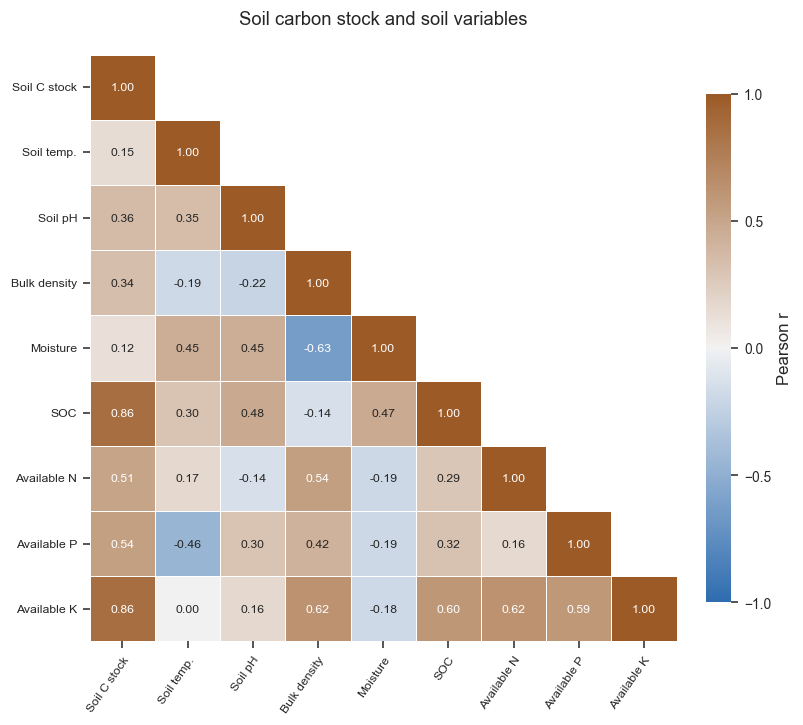

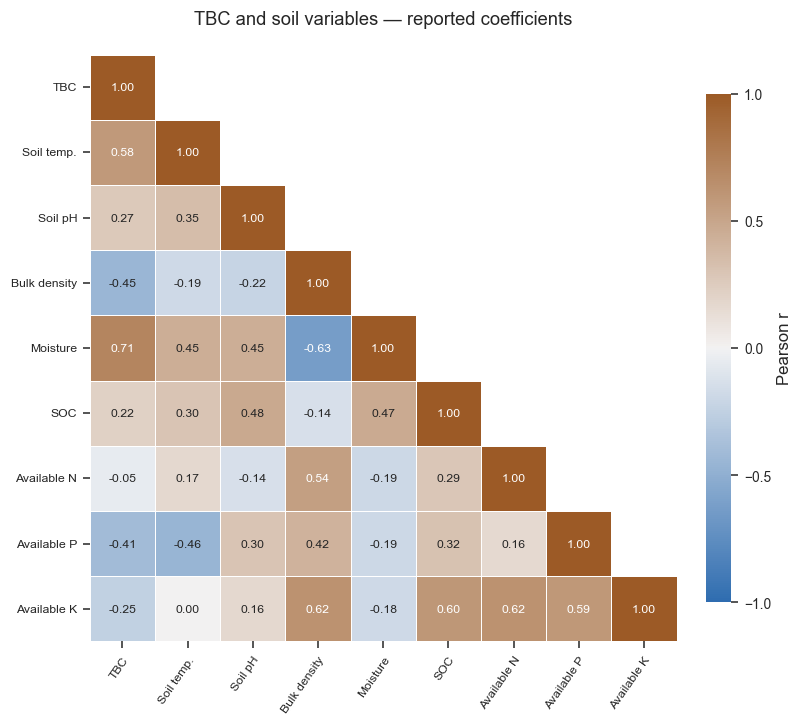

In [3]:
def plot_matrix(sheet):
    r = matrices[sheet]["r"].rename(index=short, columns=short)
    size = 7.2
    fig, ax = plt.subplots(figsize=(size, size), layout="constrained")
    sns.heatmap(r, mask=np.triu(np.ones(r.shape,dtype=bool), k=1),
                vmin=-1, vmax=1, center=0, cmap=CMAP, square=True,
                annot=len(r)<=9, fmt=".2f", annot_kws={"fontsize":8},
                linewidths=0.6, linecolor="white",
                cbar_kws={"label":"Pearson r", "shrink":0.65, "ticks":[-1,-0.5,0,0.5,1]}, ax=ax)
    ax.set_title(titles[sheet], pad=20)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=55, ha="right", rotation_mode="anchor", fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=8)
    save_show(fig, sheet)

plot_matrix("heatmap1")
plot_matrix("heatmap2")

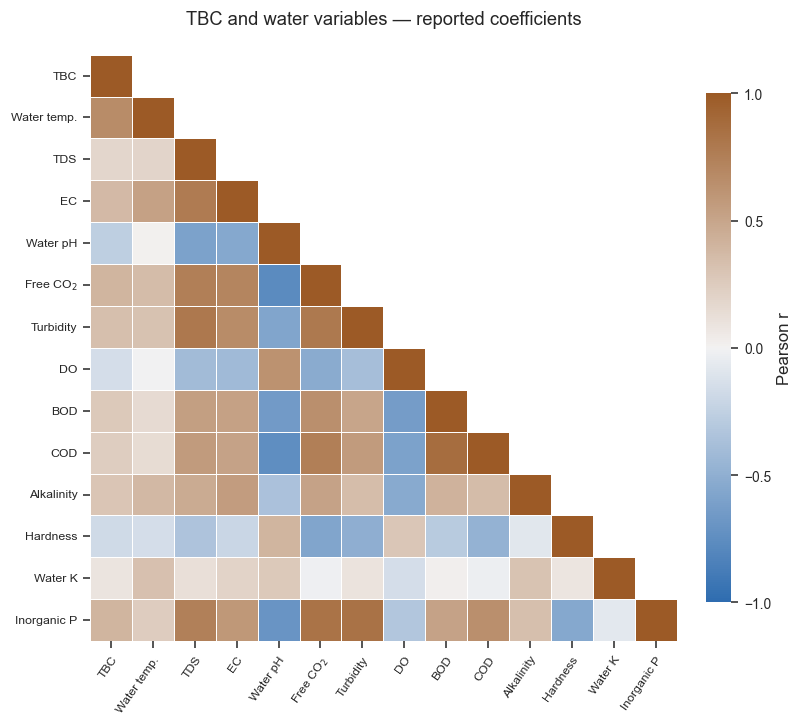

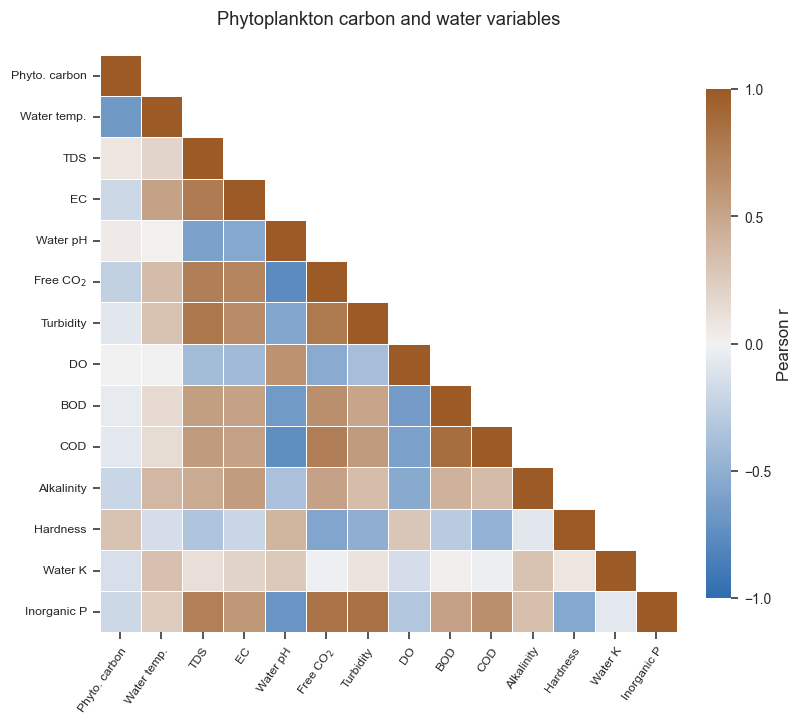

In [4]:
plot_matrix("heatmap3")
plot_matrix("heatmap4")

## 2. Carbon-response overview

These compact panels retain every environmental association with the carbon responses.
Soil and water variables remain separate; identical names such as potassium can refer
to different measurements in the two compartments. TBC entries are supplied coefficients.

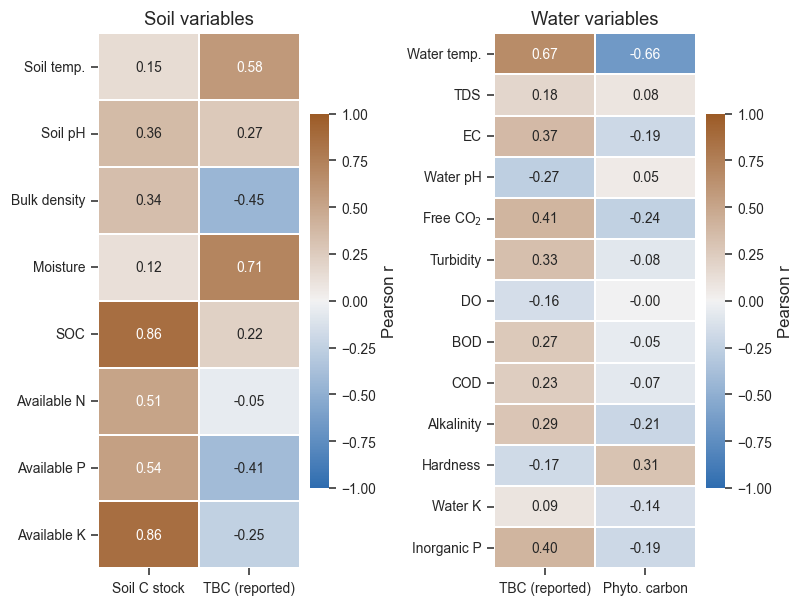

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(7.2, 5.4), layout="constrained")
for ax, sheets, labels, title in [
    (axes[0], ["heatmap1","heatmap2"], ["Soil C stock","TBC (reported)"], "Soil variables"),
    (axes[1], ["heatmap3","heatmap4"], ["TBC (reported)","Phyto. carbon"], "Water variables"),
]:
    overview = pd.concat([matrices[s]["r"].iloc[0,1:].rename(label) for s,label in zip(sheets,labels)],axis=1)
    overview = overview.rename(index=short)
    sns.heatmap(overview, annot=True, fmt=".2f", cmap=CMAP, vmin=-1, vmax=1, center=0,
                linewidths=1, annot_kws={"fontsize":9},
                cbar_kws={"label":"Pearson r", "shrink":0.7}, ax=ax)
    ax.set(title=title, xlabel="", ylabel="")
    ax.tick_params(axis="x", rotation=0)
    ax.tick_params(axis="y", rotation=0)
save_show(fig, "carbon_response_overview")

## 3. Compare exported coefficients with the available observations

For soil stock and phytoplankton carbon, recompute the **entire** matrix using keyed
joins to the supplied environmental observations. For TBC sheets, check the environmental
submatrix only. Differences up to about $5\times10^{-4}$ can reflect three-decimal
rounding in exported cells. Larger discrepancies are retained for inspection; the heatmaps
above continue to show the original coefficients, not replacements.

For these files, the maximum absolute differences are **0.00854** for soil-variable
matrices and **0.00348** for water-variable matrices. These exceed rounding of the
exported coefficients alone; underlying measurement precision or dataset versions may
differ. The available files do not identify the cause.

In [6]:
scatter, _ = load_scatter()
environment = {name:decode_pca(frame) for name,frame in load_pca().items()}
soil = environment["Soil"].merge(scatter[KEYS+["Soil_Temp","Soil_stock"]], on=KEYS, validate="one_to_one")
water = environment["Water"].merge(scatter[KEYS+["Phyto_carbon"]], on=KEYS, validate="one_to_one")
soil_names = {"Soil Carbon Stock":"Soil_stock", "soil temperature":"Soil_Temp", "pH":"Soil_pH",
              "bulk density":"BD", "soil moisture":"Moisture", "SOC":"SOC",
              "available nitrogen":"N", "available phosphorus":"P", "available potassium":"K"}
water_names = {"Phytoplankton carbon":"Phyto_carbon", "water temperature":"Water_Temp",
               "TDS":"TDS", "EC":"EC", "water pH":"Water_pH", "co2":"CO2", "Turbidity":"Turbidity",
               "do":"DO", "bod":"BOD", "cod":"COD", "alkalinity":"Alkalinity", "hardness":"Hardness",
               "Potassium":"Water_K", "inorganic phosphorus":"Inorg_P"}
checks = []
for sheet, source, names in [("heatmap1",soil,soil_names),("heatmap2",soil,soil_names),
                              ("heatmap3",water,water_names),("heatmap4",water,water_names)]:
    supplied = matrices[sheet]["r"]
    usable = [label for label in supplied if label in names]
    recalculated = source[[names[label] for label in usable]].corr()
    recalculated.index = recalculated.columns = usable
    recalculated.to_csv(TABLE_DIR / f"{sheet}_r_recalculated_available_variables.csv")
    for i, a in enumerate(usable):
        for b in usable[:i]:
            checks.append({"Sheet":sheet, "Variable A":a, "Variable B":b,
                           "Reported r":supplied.loc[a,b], "Recomputed r":recalculated.loc[a,b],
                           "Absolute difference":abs(supplied.loc[a,b]-recalculated.loc[a,b])})
checks = pd.DataFrame(checks)
display(checks.groupby("Sheet")["Absolute difference"].agg(["count","max"]))
display(checks.loc[checks["Absolute difference"] > 0.00051].sort_values("Absolute difference",ascending=False))
checks.to_csv(TABLE_DIR / "correlation_source_audit.csv", index=False)
print("TBC response correlations remain unverified because authentic raw TBC is unavailable.")

,count,max
Sheet,,
heatmap1,36,0.008539
heatmap2,28,0.008539
heatmap3,78,0.003475
heatmap4,91,0.003475


,Sheet,Variable A,Variable B,Reported r,Recomputed r,Absolute difference
24,heatmap1,available phosphorus,bulk density,0.417000,0.425539,0.008539
53,heatmap2,available phosphorus,bulk density,0.417000,0.425539,0.008539
44,heatmap2,SOC,bulk density,-0.137983,-0.130732,0.007251
13,heatmap1,SOC,bulk density,-0.137983,-0.130732,0.007251
38,heatmap2,bulk density,pH,-0.224000,-0.217778,0.006222
...,...,...,...,...,...,...
220,heatmap4,inorganic phosphorus,Phytoplankton carbon,-0.189412,-0.190081,0.000669
96,heatmap3,cod,co2,0.754000,0.754625,0.000625
183,heatmap4,cod,co2,0.754000,0.754625,0.000625
221,heatmap4,inorganic phosphorus,water temperature,0.244000,0.244524,0.000524


TBC response correlations remain unverified because authentic raw TBC is unavailable.


## Interpretation

A large |r| indicates a strong pooled linear association. It does not isolate a wetland,
seasonal or site effect. Compare the grouped scatter plots in notebook 01 before assigning
ecological meaning. Strongly correlated environmental variables can also have similar PCA
loadings; notebook 03 shows those multivariate patterns without fitting a carbon-response model.

## Conclusions and reporting guidance

- **Soil carbon stock and SOC** have a large reported positive correlation, but these measures are **mathematically coupled** because SOC is an input to carbon-stock calculation. Do not describe this as independent mechanistic evidence.
- Reported TBC relationships with soil moisture and water temperature may be interesting, but authentic site-level TBC values are needed before independent verification or regression analysis.
- A reported negative association between phytoplankton carbon and water temperature warrants seasonal and wetland-stratified analysis before ecological interpretation.
- The figures describe **pooled Pearson associations**. Their nominal significance marks are intentionally omitted from the figures because repeated sampling and multiple testing are not accounted for. Consider hierarchical or within-site analyses and false-discovery-rate control for any confirmatory claims.
- These correlations should be discussed in relation to hydrology and productivity without implying causation.